In [14]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [16]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [17]:
df = df.dropna()

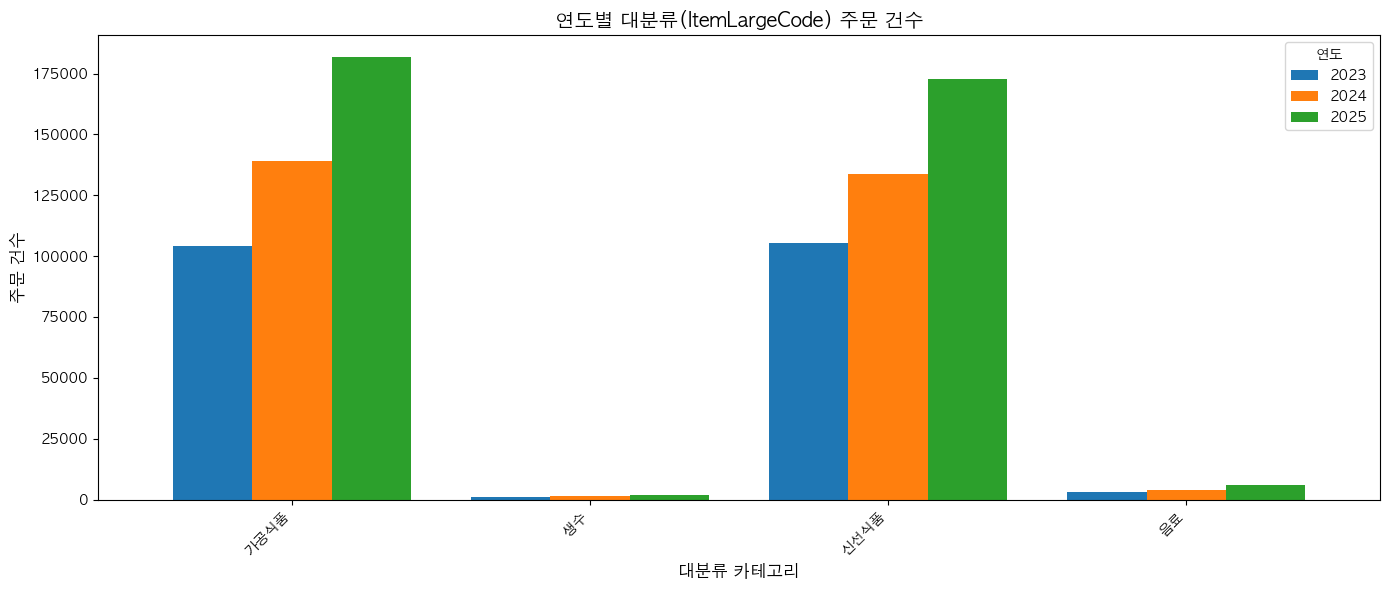

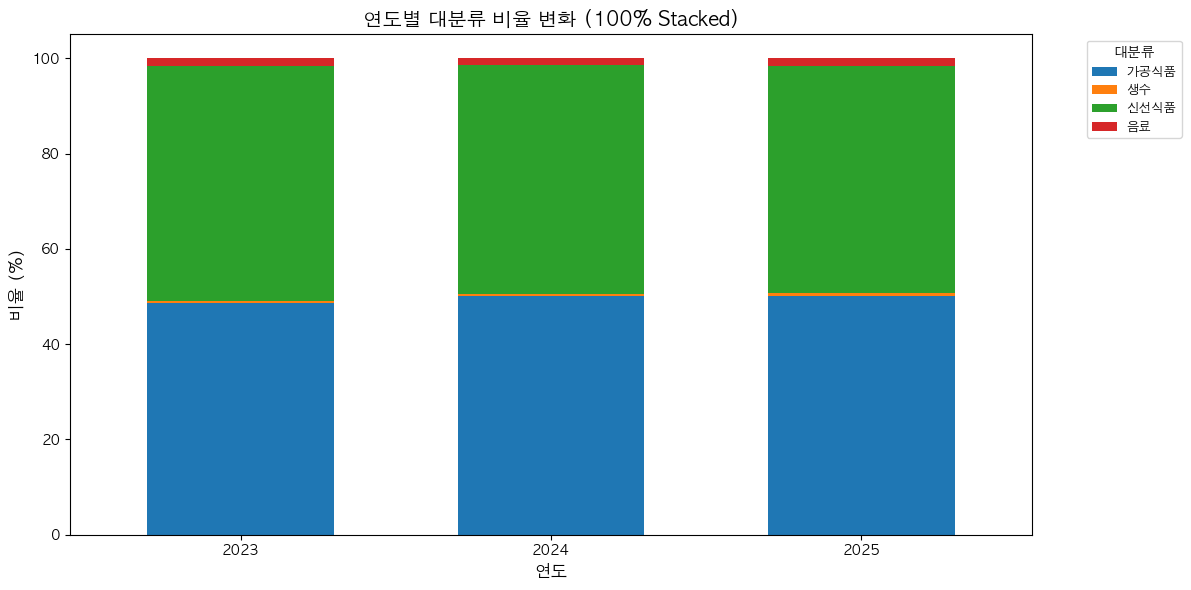

[대분류] 연도별 주문 건수 요약
OrderYear        2023    2024    2025
ItemLargeName                        
가공식품           103974  139097  181634
생수               1010    1337    1894
신선식품           105345  133726  172945
음료               3266    3962    5911

연도별 총 주문 건수: OrderYear
2023    213595
2024    278122
2025    362384
dtype: int64
연도별 대분류 개수: OrderYear
2023    4
2024    4
2025    4
dtype: int64


In [18]:
# ===== 섹션 1: 대분류(대코드) 연도별 분석 =====
# 대분류별 연도별 주문 건수
yearly_large = df.groupby(['OrderYear', 'ItemLargeName']).size().reset_index(name='count')
pivot_large = yearly_large.pivot(index='ItemLargeName', columns='OrderYear', values='count').fillna(0)

# 차트 1-1: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))
pivot_large.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('연도별 대분류(ItemLargeCode) 주문 건수', fontsize=14, fontweight='bold')
ax.set_xlabel('대분류 카테고리', fontsize=12)
ax.set_ylabel('주문 건수', fontsize=12)
ax.legend(title='연도', labels=[str(int(x)) for x in pivot_large.columns])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 차트 1-2: 100% Stacked Bar Chart (연도별 구성 비율)
fig, ax = plt.subplots(figsize=(12, 6))
pivot_large_pct = pivot_large.div(pivot_large.sum(axis=0), axis=1) * 100
pivot_large_pct.T.plot(kind='bar', stacked=True, ax=ax, width=0.6)
ax.set_title('연도별 대분류 비율 변화 (100% Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('비율 (%)', fontsize=12)
ax.legend(title='대분류', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([str(int(x)) for x in pivot_large.columns], rotation=0)
plt.tight_layout()
plt.show()

# 통계 요약
print('=' * 60)
print('[대분류] 연도별 주문 건수 요약')
print('=' * 60)
print(pivot_large)
print('\n연도별 총 주문 건수:', pivot_large.sum())
print('연도별 대분류 개수:', (pivot_large > 0).sum())

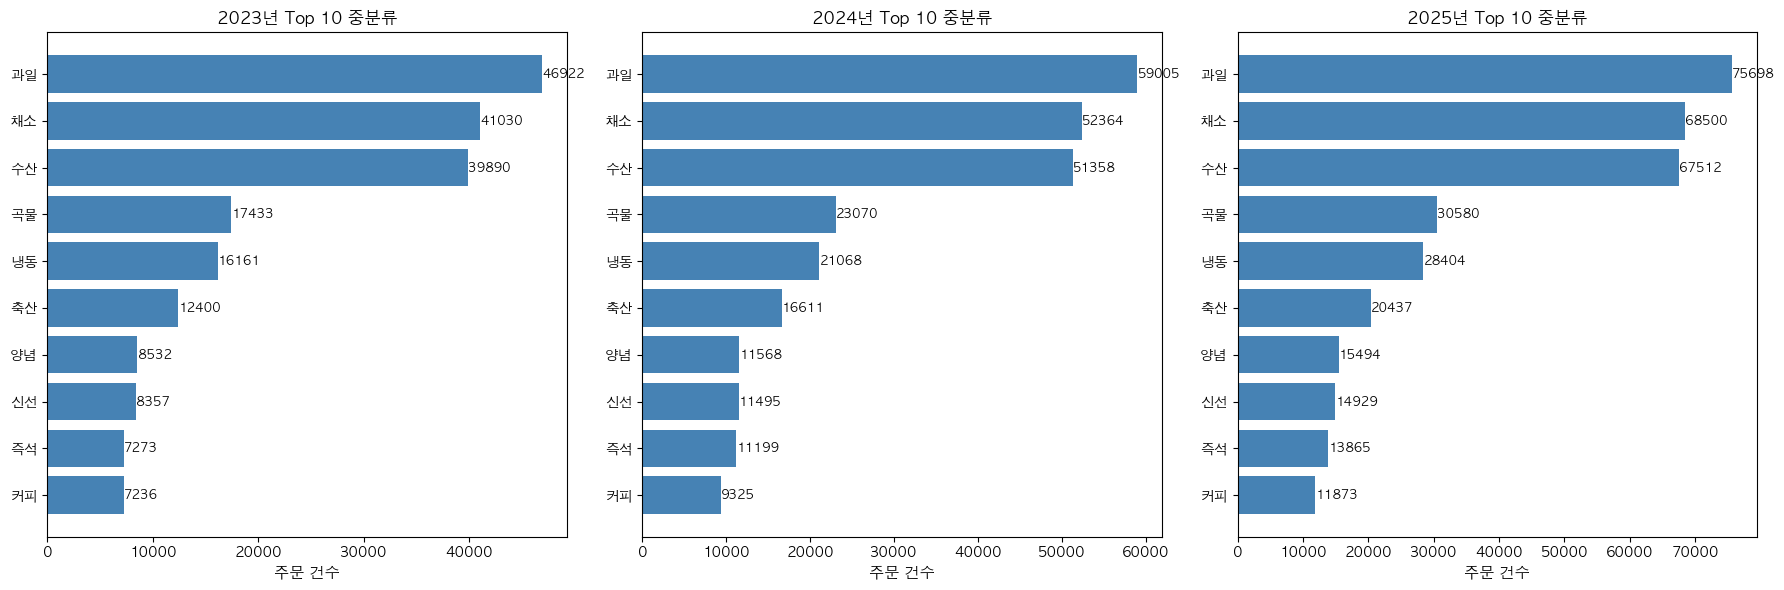

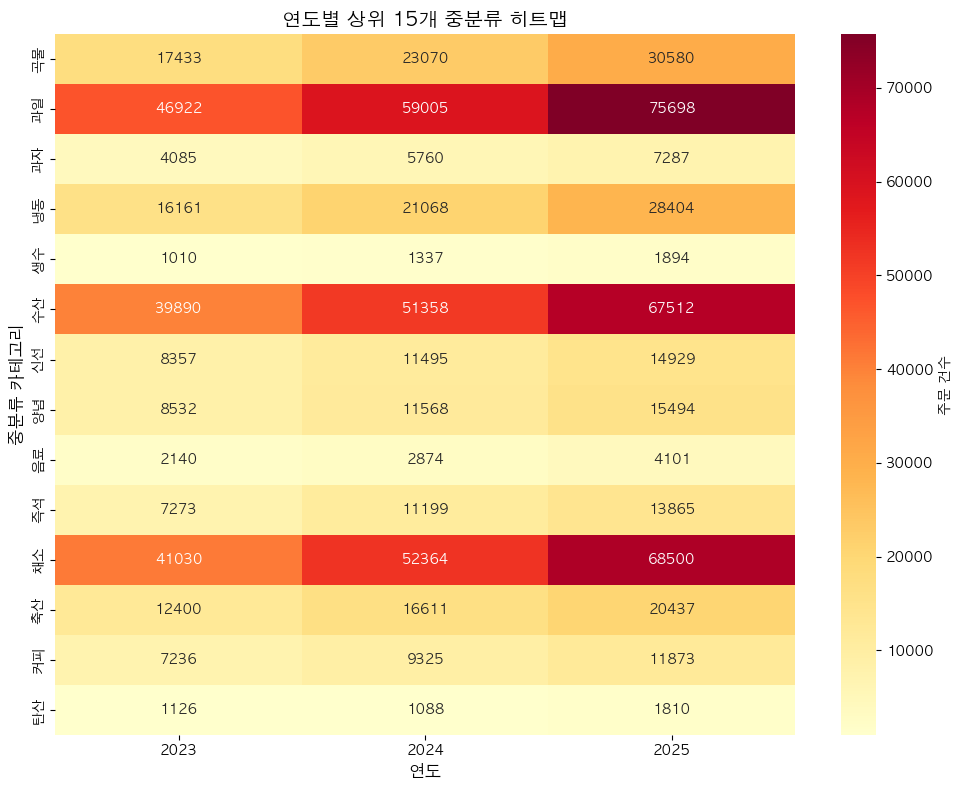

[중분류] 연도별 주문 건수 (상위 15개)
OrderYear        2023   2024   2025
ItemMiddleName                     
곡물              17433  23070  30580
과일              46922  59005  75698
과자               4085   5760   7287
냉동              16161  21068  28404
생수               1010   1337   1894
수산              39890  51358  67512
신선               8357  11495  14929
양념               8532  11568  15494
음료               2140   2874   4101
즉석               7273  11199  13865
채소              41030  52364  68500
축산              12400  16611  20437
커피               7236   9325  11873
탄산               1126   1088   1810

연도별 고유 중분류 개수: OrderYear
2023    14
2024    14
2025    14
Name: ItemMiddleName, dtype: int64


In [19]:
# ===== 섹션 2: 중분류(중코드) 연도별 분석 =====
# 연도별 Top 10 중분류 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, year in enumerate(sorted(df['OrderYear'].unique())):
    year_data = df[df['OrderYear'] == year]
    top_middle = year_data['ItemMiddleName'].value_counts().head(10)
    
    axes[idx].barh(range(len(top_middle)), top_middle.values, color='steelblue')
    axes[idx].set_yticks(range(len(top_middle)))
    axes[idx].set_yticklabels(top_middle.index, fontsize=10)
    axes[idx].set_xlabel('주문 건수', fontsize=11)
    axes[idx].set_title(f'{int(year)}년 Top 10 중분류', fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()
    
    # 각 바의 값 표시
    for i, v in enumerate(top_middle.values):
        axes[idx].text(v + 20, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 차트 2-2: 중분류 히트맵 (연도 x 중분류)
yearly_middle = df.groupby(['OrderYear', 'ItemMiddleName']).size().reset_index(name='count')

# 상위 15개 중분류 선별
top_15_middle = df['ItemMiddleName'].value_counts().head(15).index.tolist()
yearly_middle_filtered = yearly_middle[yearly_middle['ItemMiddleName'].isin(top_15_middle)]
pivot_middle = yearly_middle_filtered.pivot(index='ItemMiddleName', columns='OrderYear', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_middle, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '주문 건수'}, ax=ax)
ax.set_title('연도별 상위 15개 중분류 히트맵', fontsize=14, fontweight='bold')
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('중분류 카테고리', fontsize=12)
ax.set_xticklabels([str(int(x)) for x in pivot_middle.columns], rotation=0)
plt.tight_layout()
plt.show()

# 통계 요약
print('=' * 60)
print('[중분류] 연도별 주문 건수 (상위 15개)')
print('=' * 60)
print(pivot_middle)
print('\n연도별 고유 중분류 개수:', yearly_middle.groupby('OrderYear')['ItemMiddleName'].nunique())

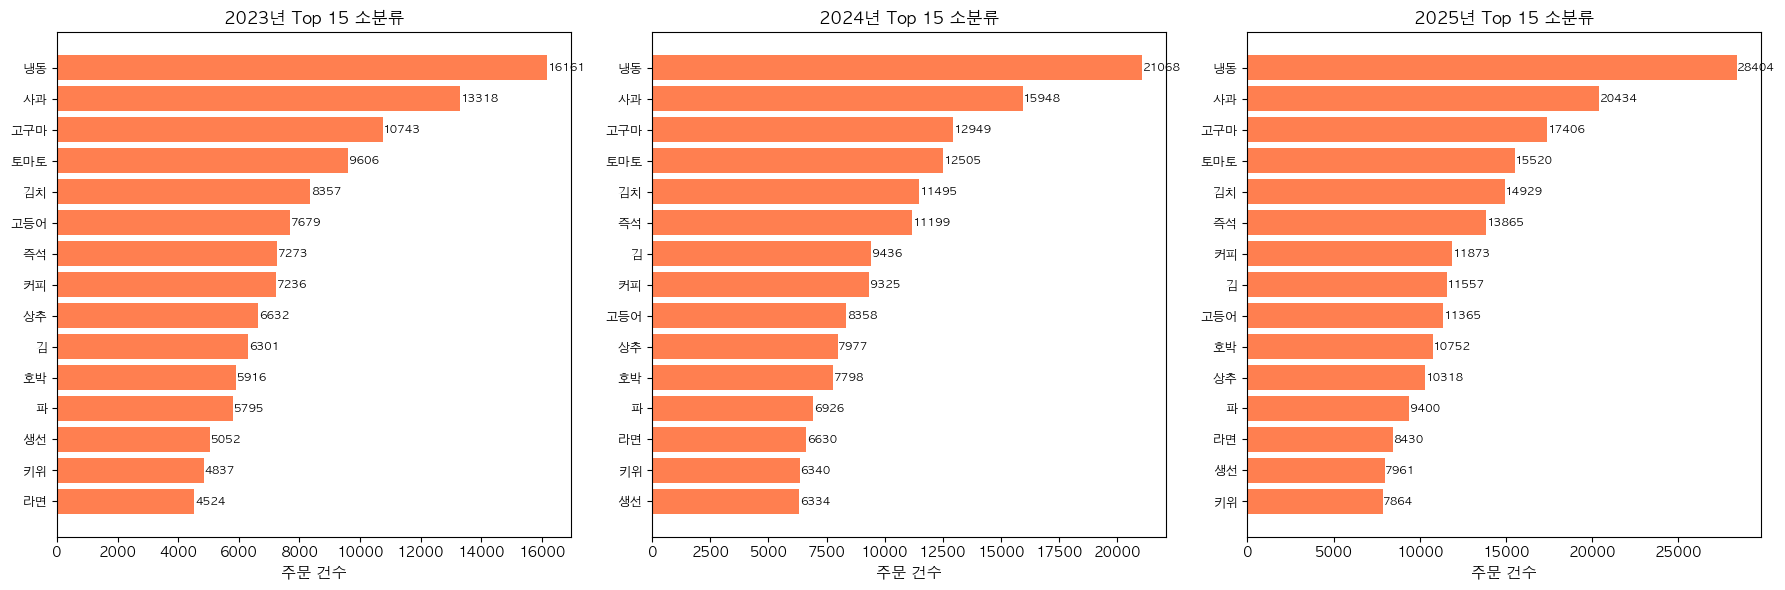

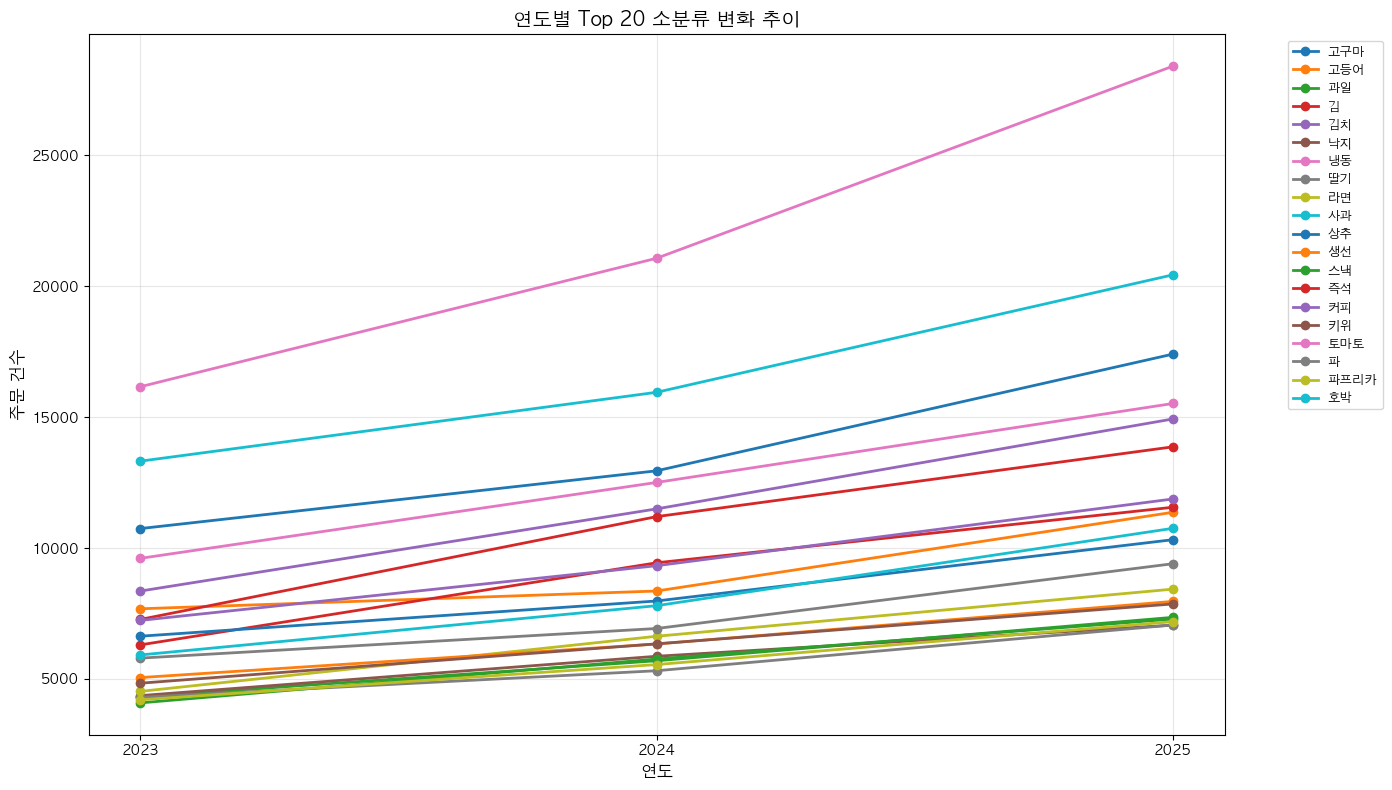

[소분류] 연도별 주문 건수 (상위 20개)
OrderYear       2023   2024   2025
ItemSmallName                     
고구마            10743  12949  17406
고등어             7679   8358  11365
과일              4315   5694   7352
김               6301   9436  11557
김치              8357  11495  14929
낙지              4363   5866   7055
냉동             16161  21068  28404
딸기              4296   5313   7061
라면              4524   6630   8430
사과             13318  15948  20434
상추              6632   7977  10318
생선              5052   6334   7961
스낵              4085   5760   7287
즉석              7273  11199  13865
커피              7236   9325  11873
키위              4837   6340   7864
토마토             9606  12505  15520
파               5795   6926   9400
파프리카            4203   5549   7188
호박              5916   7798  10752

연도별 고유 소분류 개수: OrderYear
2023    58
2024    58
2025    58
Name: ItemSmallName, dtype: int64


In [20]:
# ===== 섹션 3: 소분류(소코드) 연도별 분석 =====
# 연도별 Top 15 소분류 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, year in enumerate(sorted(df['OrderYear'].unique())):
    year_data = df[df['OrderYear'] == year]
    top_small = year_data['ItemSmallName'].value_counts().head(15)
    
    axes[idx].barh(range(len(top_small)), top_small.values, color='coral')
    axes[idx].set_yticks(range(len(top_small)))
    axes[idx].set_yticklabels(top_small.index, fontsize=9)
    axes[idx].set_xlabel('주문 건수', fontsize=11)
    axes[idx].set_title(f'{int(year)}년 Top 15 소분류', fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()
    
    # 각 바의 값 표시
    for i, v in enumerate(top_small.values):
        axes[idx].text(v + 30, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

# 차트 3-2: Top 20 소분류의 연도별 변화 라인 차트
yearly_small = df.groupby(['OrderYear', 'ItemSmallName']).size().reset_index(name='count')

# 전체 기간 Top 20 소분류 선별
top_20_small = df['ItemSmallName'].value_counts().head(20).index.tolist()
yearly_small_filtered = yearly_small[yearly_small['ItemSmallName'].isin(top_20_small)]
pivot_small = yearly_small_filtered.pivot(index='ItemSmallName', columns='OrderYear', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
for item in pivot_small.index:
    ax.plot(pivot_small.columns, pivot_small.loc[item], marker='o', label=item, linewidth=2, markersize=6)

ax.set_title('연도별 Top 20 소분류 변화 추이', fontsize=14, fontweight='bold')
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('주문 건수', fontsize=12)
ax.set_xticks(sorted(df['OrderYear'].unique()))
ax.set_xticklabels([str(int(x)) for x in sorted(df['OrderYear'].unique())])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 통계 요약
print('=' * 60)
print('[소분류] 연도별 주문 건수 (상위 20개)')
print('=' * 60)
print(pivot_small)
print('\n연도별 고유 소분류 개수:', yearly_small.groupby('OrderYear')['ItemSmallName'].nunique())

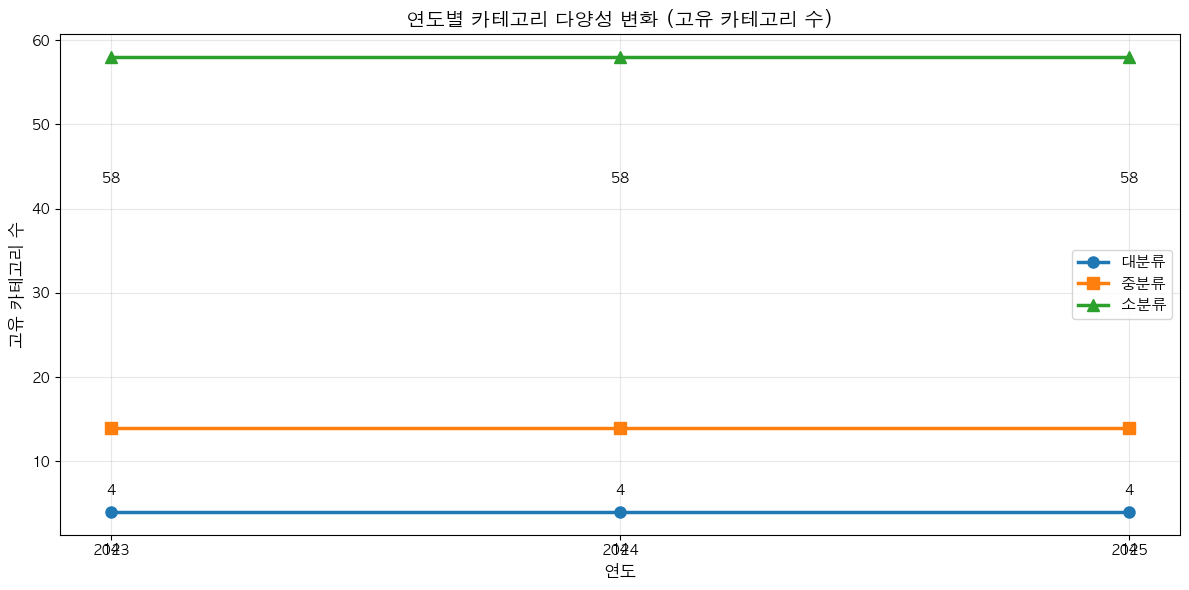

[종합 통계] 연도별 카테고리 분석
           대분류 고유수  중분류 고유수  소분류 고유수  총 주문건수
OrderYear                                   
2023             4       14       58  213595
2024             4       14       58  278122
2025             4       14       58  362384

[성장률] 2023년 대비 변화
대분류 고유수:
  2023년: +0.0%
  2024년: +0.0%
  2025년: +0.0%

중분류 고유수:
  2023년: +0.0%
  2024년: +0.0%
  2025년: +0.0%

소분류 고유수:
  2023년: +0.0%
  2024년: +0.0%
  2025년: +0.0%

총 주문건수:
  2023년: +0.0%
  2024년: +30.2%
  2025년: +69.7%



In [21]:
# ===== 섹션 4: 종합 요약 분석 =====
# 연도별 고유 카테고리 수 변화
unique_large = df.groupby('OrderYear')['ItemLargeName'].nunique()
unique_middle = df.groupby('OrderYear')['ItemMiddleName'].nunique()
unique_small = df.groupby('OrderYear')['ItemSmallName'].nunique()

fig, ax = plt.subplots(figsize=(12, 6))
years = sorted(df['OrderYear'].unique())
x = np.arange(len(years))
width = 0.25

ax.plot(years, unique_large.values, marker='o', label='대분류', linewidth=2.5, markersize=8, color='#1f77b4')
ax.plot(years, unique_middle.values, marker='s', label='중분류', linewidth=2.5, markersize=8, color='#ff7f0e')
ax.plot(years, unique_small.values, marker='^', label='소분류', linewidth=2.5, markersize=8, color='#2ca02c')

ax.set_title('연도별 카테고리 다양성 변화 (고유 카테고리 수)', fontsize=14, fontweight='bold')
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('고유 카테고리 수', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

# 값 표시
for i, year in enumerate(years):
    ax.text(year, unique_large.iloc[i] + 2, str(unique_large.iloc[i]), ha='center', fontsize=10)
    ax.text(year, unique_middle.iloc[i] - 15, str(unique_middle.iloc[i]), ha='center', fontsize=10)
    ax.text(year, unique_small.iloc[i] - 15, str(unique_small.iloc[i]), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 종합 통계
print('=' * 70)
print('[종합 통계] 연도별 카테고리 분석')
print('=' * 70)
summary_stats = pd.DataFrame({
    '대분류 고유수': unique_large,
    '중분류 고유수': unique_middle,
    '소분류 고유수': unique_small,
    '총 주문건수': df.groupby('OrderYear').size()
})
print(summary_stats)

# 연도별 성장률
print('\n' + '=' * 70)
print('[성장률] 2023년 대비 변화')
print('=' * 70)
for col in summary_stats.columns:
    base = summary_stats[col].iloc[0]
    growth = ((summary_stats[col] / base) - 1) * 100
    print(f'{col}:')
    for year, rate in growth.items():
        print(f'  {int(year)}년: {rate:+.1f}%')
    print()

In [22]:
# ===== 섹션 5: 상세 비교 분석 =====
# 연도별 대분류별 상세 통계표
print('=' * 100)
print('[상세 분석] 연도별 대분류별 주문 건수 및 비율')
print('=' * 100)

detailed_large = df.groupby(['OrderYear', 'ItemLargeName']).size().reset_index(name='count')
for year in sorted(df['OrderYear'].unique()):
    year_data = detailed_large[detailed_large['OrderYear'] == year].copy()
    year_total = year_data['count'].sum()
    year_data['비율(%)'] = (year_data['count'] / year_total * 100).round(2)
    year_data = year_data.sort_values('count', ascending=False)
    
    print(f'\n[{int(year)}년]')
    print('-' * 80)
    for idx, row in year_data.iterrows():
        large_name = row['ItemLargeName']
        count = int(row['count'])
        ratio = row['비율(%)']
        print(f'  {large_name:20s} | 건수: {count:6d} ({ratio:5.1f}%)')
    print(f'  Total: {year_total:6d}')

# 연도별 Top 3 카테고리 비교
print('\n' + '=' * 100)
print('[Top 3 비교] 각 연도별 가장 인기있는 대분류')
print('=' * 100)

for year in sorted(df['OrderYear'].unique()):
    year_data = detailed_large[detailed_large['OrderYear'] == year].copy()
    year_total = year_data['count'].sum()
    top3 = year_data.nlargest(3, 'count')
    top3_pct = (top3['count'].sum() / year_total * 100)
    
    print(f'\n[{int(year)}년]')
    for rank, (idx, row) in enumerate(top3.iterrows(), 1):
        large_name = row['ItemLargeName']
        count = int(row['count'])
        pct = row['count'] / year_total * 100
        print(f'  {rank}위: {large_name:20s} - {count:6d}건 ({pct:5.1f}%)')
    print(f'  Top 3 합계: {int(top3["count"].sum()):6d}건 ({top3_pct:5.1f}%) → 전체 주문의 {top3_pct:.1f}%')

[상세 분석] 연도별 대분류별 주문 건수 및 비율

[2023년]
--------------------------------------------------------------------------------
  신선식품                 | 건수: 105345 ( 49.3%)
  가공식품                 | 건수: 103974 ( 48.7%)
  음료                   | 건수:   3266 (  1.5%)
  생수                   | 건수:   1010 (  0.5%)
  Total: 213595

[2024년]
--------------------------------------------------------------------------------
  가공식품                 | 건수: 139097 ( 50.0%)
  신선식품                 | 건수: 133726 ( 48.1%)
  음료                   | 건수:   3962 (  1.4%)
  생수                   | 건수:   1337 (  0.5%)
  Total: 278122

[2025년]
--------------------------------------------------------------------------------
  가공식품                 | 건수: 181634 ( 50.1%)
  신선식품                 | 건수: 172945 ( 47.7%)
  음료                   | 건수:   5911 (  1.6%)
  생수                   | 건수:   1894 (  0.5%)
  Total: 362384

[Top 3 비교] 각 연도별 가장 인기있는 대분류

[2023년]
  1위: 신선식품                 - 105345건 ( 49.3%)
  2위: 가공식품                 - 

[카테고리 집중도] HHI 분석 (Herfindahl-Hirschman Index)
HHI 해석: 0 ~ 1500: 낮음(분산) | 1500 ~ 2500: 중간 | 2500 이상: 높음(집중)

[2023년] 대분류 HHI: 4804.58 - 높음(집중)
[2024년] 대분류 HHI: 4815.41 - 높음(집중)
[2025년] 대분류 HHI: 4792.75 - 높음(집중)

[2023년] 중분류 HHI: 1417.41 - 낮음(분산)
[2024년] 중분류 HHI: 1375.01 - 낮음(분산)
[2025년] 중분류 HHI: 1371.65 - 낮음(분산)

[2023년] 소분류 HHI:  300.52 - 낮음(분산)
[2024년] 소분류 HHI:  295.95 - 낮음(분산)
[2025년] 소분류 HHI:  295.67 - 낮음(분산)


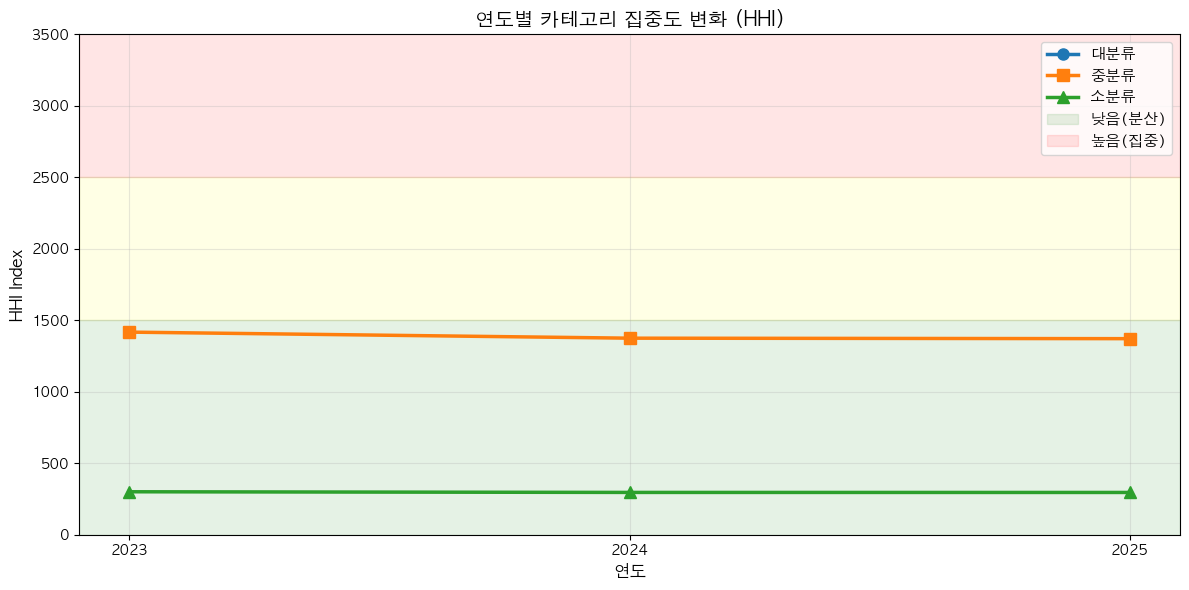


[결론] 카테고리 다양성 추이
- HHI가 감소하는 추세 = 카테고리가 더 분산됨 (다양한 상품 주문)
- HHI가 증가하는 추세 = 특정 카테고리로 집중됨 (인기 상품에 주문 집중)


In [23]:
# ===== 섹션 6: 카테고리 집중도 분석 (HHI - Herfindahl-Hirschman Index) =====
# 시장 집중도 분석: HHI 계산 (0~10000 사이, 높을수록 집중도 높음)

def calculate_hhi(series):
    """HHI 계산: 시장점유율의 제곱의 합"""
    total = series.sum()
    shares = (series / total * 100) ** 2
    return shares.sum()

print('=' * 100)
print('[카테고리 집중도] HHI 분석 (Herfindahl-Hirschman Index)')
print('=' * 100)
print('HHI 해석: 0 ~ 1500: 낮음(분산) | 1500 ~ 2500: 중간 | 2500 이상: 높음(집중)')
print()

# 대분류 HHI
hhi_large = {}
for year in sorted(df['OrderYear'].unique()):
    year_data = df[df['OrderYear'] == year]['ItemLargeName'].value_counts()
    hhi = calculate_hhi(year_data)
    hhi_large[int(year)] = hhi
    
    concentration = '낮음(분산)' if hhi < 1500 else ('중간' if hhi < 2500 else '높음(집중)')
    print(f'[{int(year)}년] 대분류 HHI: {hhi:7.2f} - {concentration}')

# 중분류 HHI
print()
hhi_middle = {}
for year in sorted(df['OrderYear'].unique()):
    year_data = df[df['OrderYear'] == year]['ItemMiddleName'].value_counts()
    hhi = calculate_hhi(year_data)
    hhi_middle[int(year)] = hhi
    
    concentration = '낮음(분산)' if hhi < 1500 else ('중간' if hhi < 2500 else '높음(집중)')
    print(f'[{int(year)}년] 중분류 HHI: {hhi:7.2f} - {concentration}')

# 소분류 HHI
print()
hhi_small = {}
for year in sorted(df['OrderYear'].unique()):
    year_data = df[df['OrderYear'] == year]['ItemSmallName'].value_counts()
    hhi = calculate_hhi(year_data)
    hhi_small[int(year)] = hhi
    
    concentration = '낮음(분산)' if hhi < 1500 else ('중간' if hhi < 2500 else '높음(집중)')
    print(f'[{int(year)}년] 소분류 HHI: {hhi:7.2f} - {concentration}')

# HHI 추이 시각화
fig, ax = plt.subplots(figsize=(12, 6))
years_hhi = sorted(hhi_large.keys())

ax.plot(years_hhi, [hhi_large[y] for y in years_hhi], marker='o', label='대분류', linewidth=2.5, markersize=8)
ax.plot(years_hhi, [hhi_middle[y] for y in years_hhi], marker='s', label='중분류', linewidth=2.5, markersize=8)
ax.plot(years_hhi, [hhi_small[y] for y in years_hhi], marker='^', label='소분류', linewidth=2.5, markersize=8)

# 배경색 추가 (집중도 수준)
ax.axhspan(0, 1500, alpha=0.1, color='green', label='낮음(분산)')
ax.axhspan(1500, 2500, alpha=0.1, color='yellow')
ax.axhspan(2500, 10000, alpha=0.1, color='red', label='높음(집중)')

ax.set_title('연도별 카테고리 집중도 변화 (HHI)', fontsize=14, fontweight='bold')
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('HHI Index', fontsize=12)
ax.set_xticks(years_hhi)
ax.set_xticklabels([str(y) for y in years_hhi])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 3500)

plt.tight_layout()
plt.show()

print('\n' + '=' * 100)
print('[결론] 카테고리 다양성 추이')
print('=' * 100)
print('- HHI가 감소하는 추세 = 카테고리가 더 분산됨 (다양한 상품 주문)')
print('- HHI가 증가하는 추세 = 특정 카테고리로 집중됨 (인기 상품에 주문 집중)')